# GP01 - Ejercicio 4

Dado el filtro IIR:

$$
y[n] = x[n]−x[n−1] + x[n−2] + x[n−3] + 0,5y[n−1] + 0,25y[n−2] 
$$

Si se consideran valores de 8 bits signados enteros para la entrada $x[n]$, entonces calculo el número máximo de bits necesarios para representar la salida $y[n]$ sin pérdida de información. Para ello considero el peor caso posible, es decir, cuando la entrada $x[n]$ toma los valores extremos de su rango, es decir, $x[n] = 127$ y $x[n] = -128$. Para calcular el valor máximo de $y[n]$, se puede calcular el peor caso como:

$$
y[n] = \sum_{k=-\infty}^{\infty} h[k] x[n-k] \leq \sum_{k=-\infty}^{\infty} |h[k]| |x[n-k]|
$$ 

$$
Y_{max} \leq X_{max} \sum_{k=-\infty}^{\infty} |h[k]|
$$

Lo mismo se da para $Y_{min}$ con $X_{min}$. Es posible calcular numéricamente la respuesta al impulso del filtro para obtener los valores de $h[k]$ y de esa forma calcular la cota superior de $y[n]$:

In [ ]:
from matplotlib.pyplot import (
    figure,
    grid,
    legend,
    show,
    stem,
    step,
    title,
    xlabel,
    ylabel,
    ylim,
)
from numpy import abs, arange, array, ceil, floor, log2, ones, zeros
from scipy.signal import lfilter

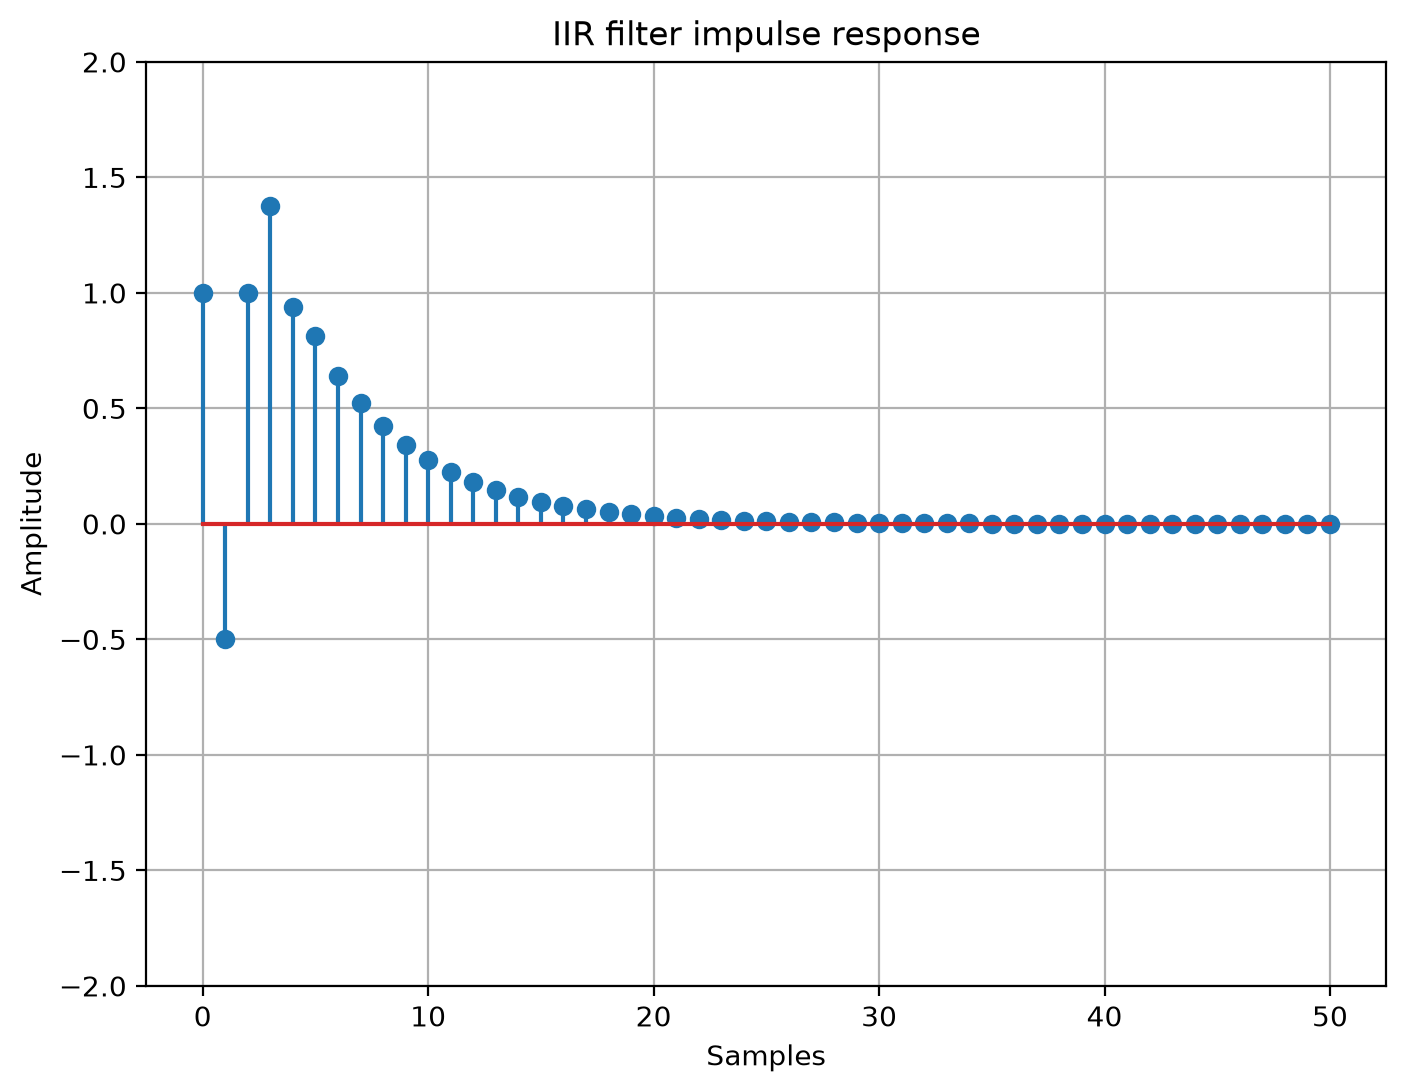

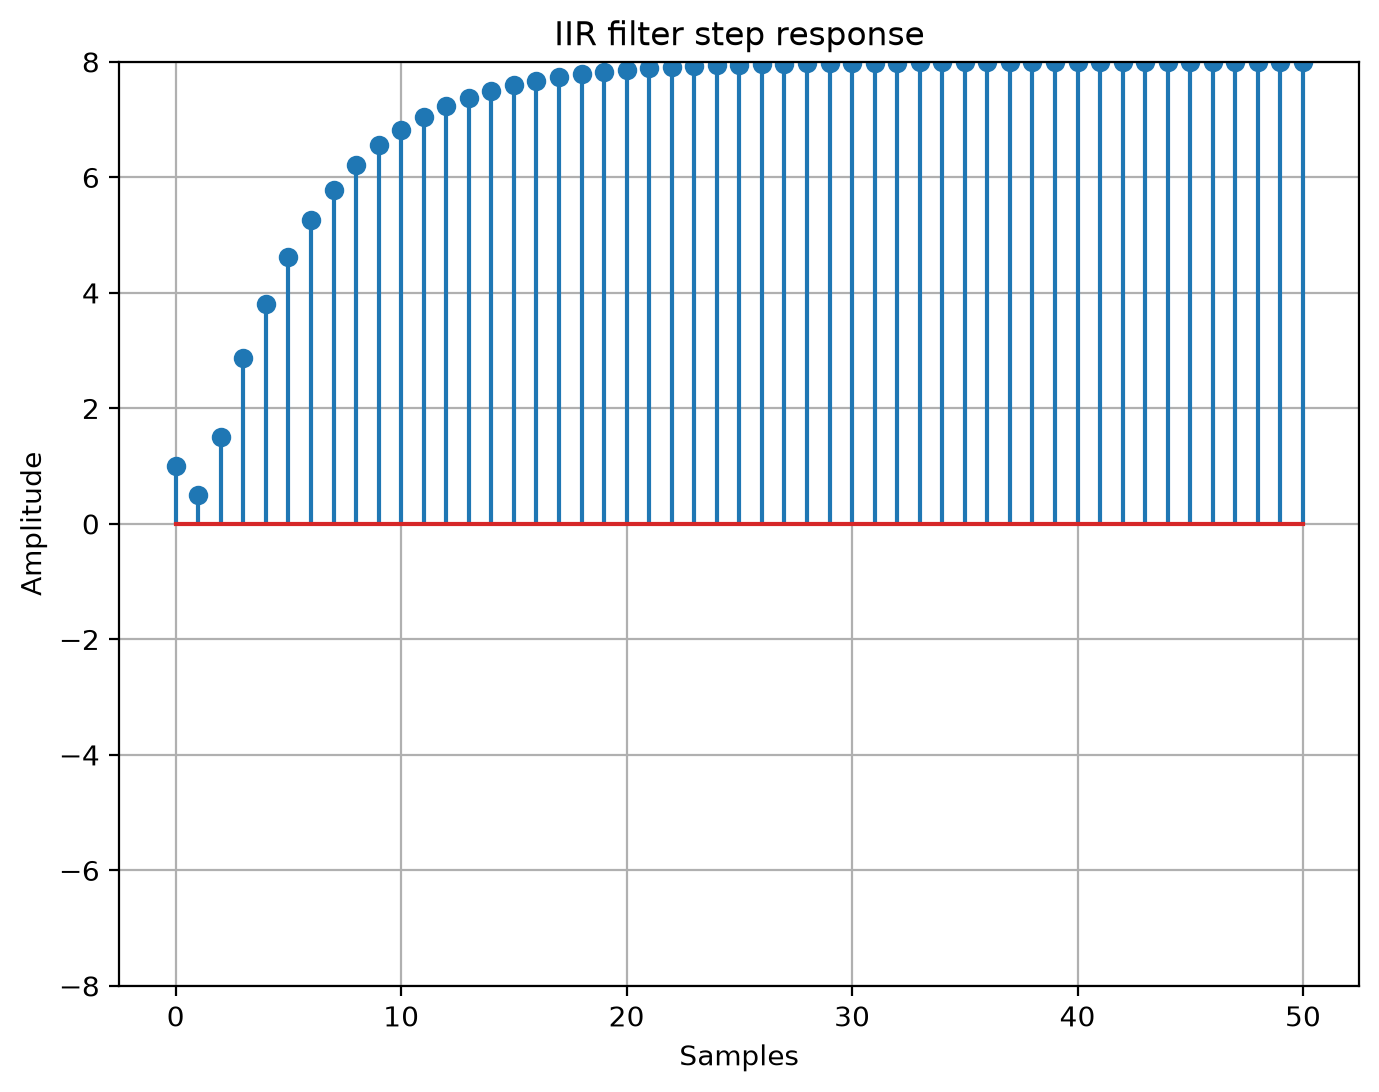

In [66]:
n_samples = 51
n = arange(n_samples)

# Filter coefficients
b = [1, -1, 1, 1]
a = [1, -0.5, -0.25]


def impulse_signal(amplitude, length):
    x = zeros(length, dtype=int)
    x[0] = amplitude
    return x


def step_signal(amplitude, length):
    x = ones(length, dtype=int) * amplitude
    return x


h_impulse = lfilter(b, a, impulse_signal(1, n_samples))
h_step = lfilter(b, a, step_signal(1, n_samples))

figure(1, figsize=(8, 6), dpi=200)
stem(n, h_impulse)
ylim((-ceil(max(h_impulse)), ceil(max(h_impulse))))
xlabel("Samples")
ylabel("Amplitude")
title("IIR filter impulse response")
grid(True)
show()

figure(1, figsize=(8, 6), dpi=200)
stem(n, h_step)
ylim((-ceil(max(h_step)), ceil(max(h_step))))
xlabel("Samples")
ylabel("Amplitude")
title("IIR filter step response")
grid(True)
show()

In [67]:
# Max. input @ 8-bits signed
x_max = 127
y_max = ceil(x_max * sum(abs(h_impulse)))

# Min. input @ 8-bits signed
x_min = -128
y_min = floor(x_min * sum(abs(h_impulse)))

y_extreme_value = min(y_min, y_max)
n_bits = int(log2(abs(y_extreme_value)) + 2)

print(
    f"The system's output ranges between {y_min} and {y_max}. Considering the symmetrical range {y_extreme_value if y_extreme_value < 0 else -y_extreme_value} to {y_extreme_value if y_extreme_value > 0 else -y_extreme_value}, {n_bits} signed bits are needed to represent the output."
)

The system's output ranges between -1152.0 and 1143.0. Considering the symmetrical range -1152.0 to 1152.0, 12 signed bits are needed to represent the output.


Para evitar overflow en la salida del filtro, son necesarios 12 bits signados, que abarcan el rango:

$$
-1152.0 \leq y[n] \leq 1152.0
$$

A continuación se muestra la implementación en punto flotante y en enteros del filtro IIR, así como la respuesta al impulso y al escalón de ambos filtros. Notar que dado que la realimentación del filtro se divide por 2 y por 4 respectivamente, con factores unitarios en la entrada, el filtro implementado se aleja mucho del comportamiento del filtro original para señales de entrada pequeñas como el impulso o escalón unitario. Para señales de mayor amplitud, el comportamiento del filtro implementado se asemeja al del filtro original.

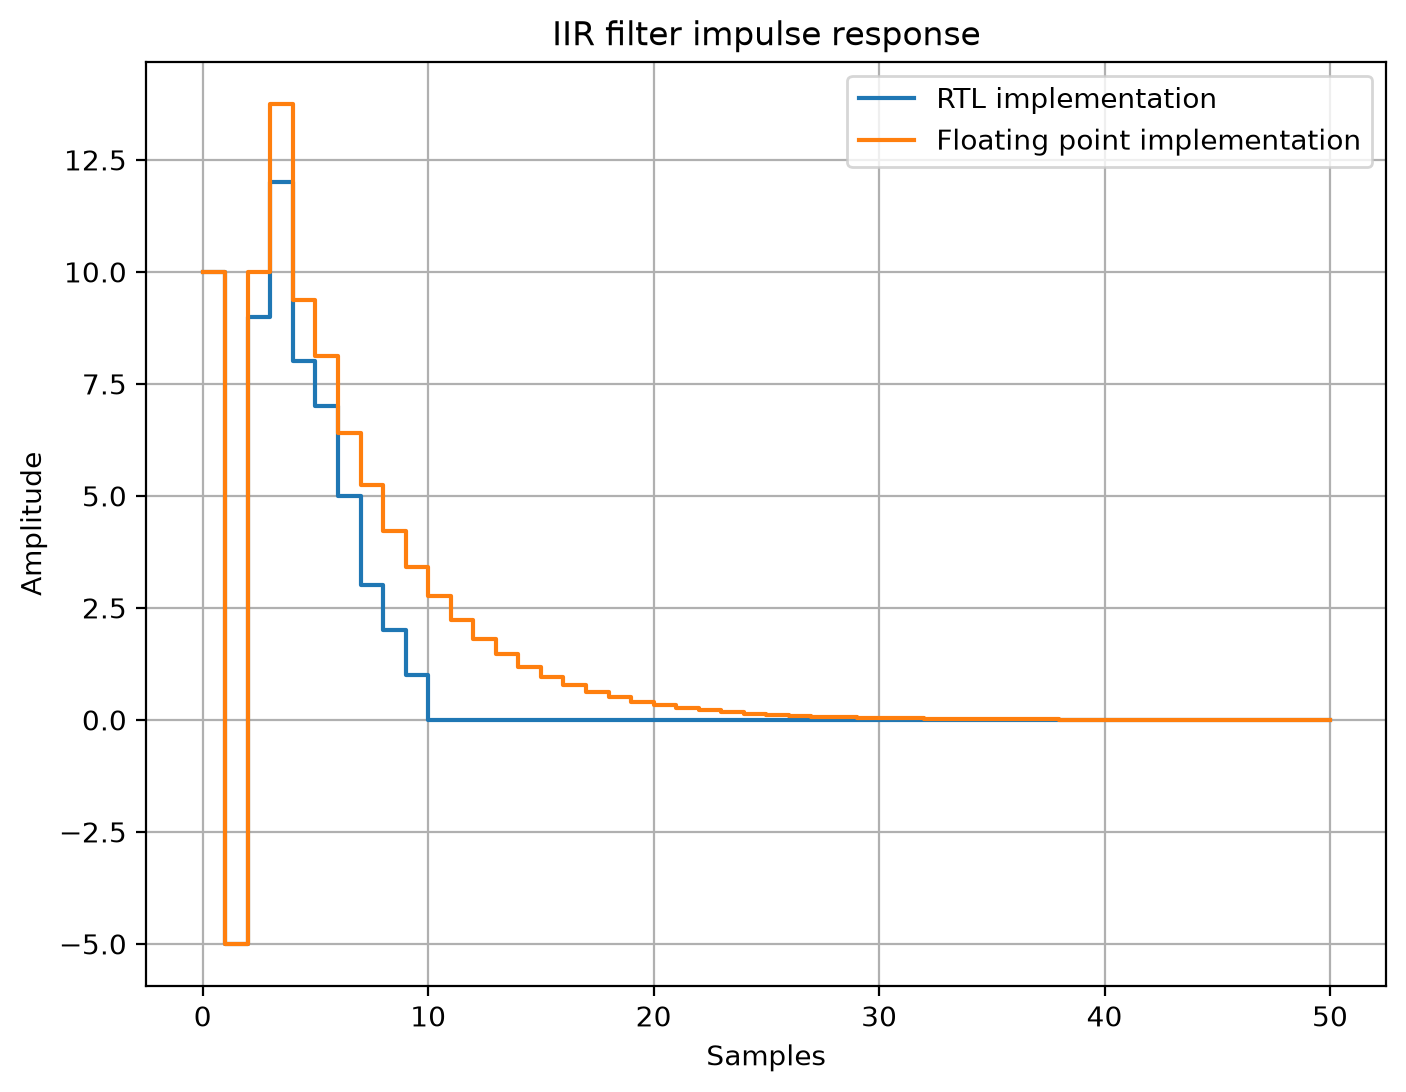

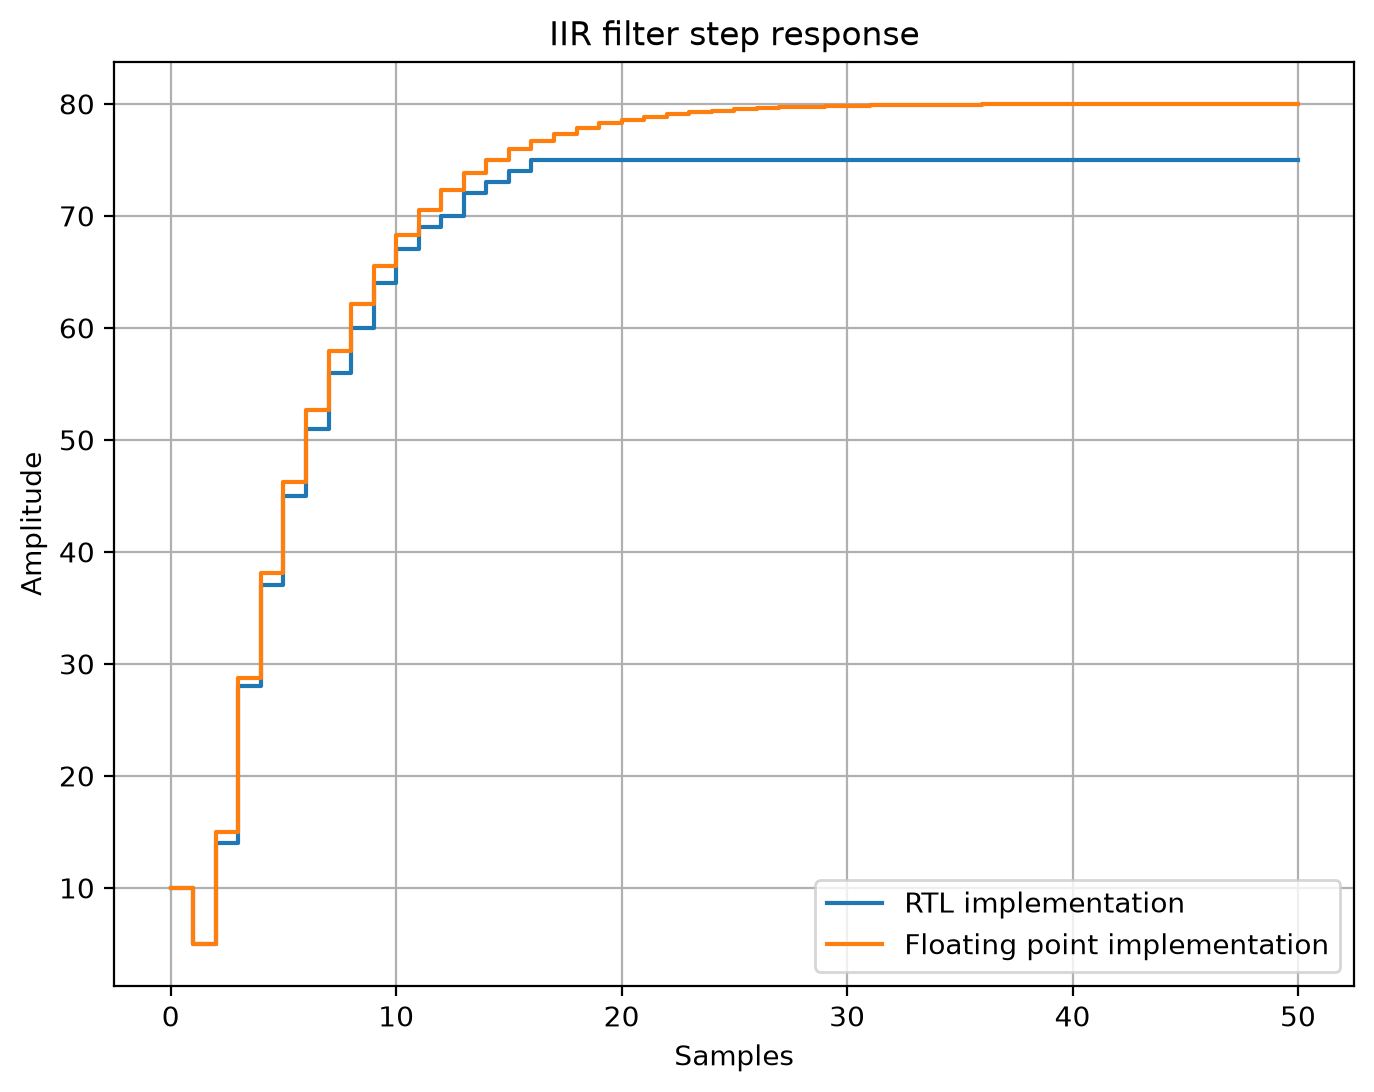

In [79]:
# Golden model for the rtl implementation
def rtl_iir_filter_implementation(x):
    x_1 = x_2 = x_3 = 0
    y_1 = y_2 = 0
    y = []
    for sample in (int(k) for k in x):
        output = sample - x_1 + x_2 + x_3 + (y_1 >> 1) + (y_2 >> 2)
        y.append(output)
        x_3, x_2, x_1 = x_2, x_1, sample
        y_2, y_1 = y_1, output
    return array(y, dtype=int)


# Modify the amplitude of the impulse and step signals to test the filter's response
amplitude = 10

x = impulse_signal(amplitude, n_samples)
y_rtl_impulse = rtl_iir_filter_implementation(x)
y_float_impulse = lfilter(b, a, x)

figure(1, figsize=(8, 6), dpi=200)
step(n, y_rtl_impulse, label="RTL implementation", where="post")
step(
    n,
    y_float_impulse,
    label="Floating point implementation",
    where="post",
)
xlabel("Samples")
ylabel("Amplitude")
title("IIR filter impulse response")
legend()
grid(True)
show()

x = step_signal(amplitude, n_samples)
y_rtl_step = rtl_iir_filter_implementation(x)
y_float_step = lfilter(b, a, x)

figure(1, figsize=(8, 6), dpi=200)
step(n, y_rtl_step, label="RTL implementation", where="post")
step(
    n,
    y_float_step,
    label="Floating point implementation",
    where="post",
)
xlabel("Samples")
ylabel("Amplitude")
title("IIR filter step response")
legend()
grid(True)
show()